# 05 - Evaluación Final y Decisión de Despliegue

## Etapa 5 del Ciclo de Vida MLOps: Gate de Calidad antes de Producción

Este es el momento más crítico del ciclo MLOps: evaluamos el modelo seleccionado en el **conjunto de test virgen** — datos que el modelo nunca ha visto durante entrenamiento ni durante la selección.

### ¿Por qué este paso es fundamental en MLOps?

- **Estimación honesta del rendimiento en producción**: el test set simula datos reales del mundo
- **Gate de calidad cuantitativo**: el modelo solo pasa a producción si supera umbrales predefinidos
- **Documentación del baseline de producción**: las métricas actuales son el punto de referencia para detectar degradación futura (model drift)

### Umbrales de aprobación para este proyecto:
- RMSE < 0.5 (error medio menor a $50,000)
- R² > 0.80 (explica más del 80% de la varianza)

Si el modelo no supera estos umbrales, se **rechaza** y volvemos a la etapa de selección.

## Prerequisitos
- Haber ejecutado: `04_seleccion_modelo.ipynb`
- Requiere: `experiments/modelo_produccion.pkl`, `experiments/scaler.pkl`, `data/processed/test.csv`
- Este notebook genera: `experiments/reporte_evaluacion.json`

## 1. Imports y Configuración

In [1]:
from pathlib import Path
import sys

# Detectar ROOT automáticamente — funciona en cualquier equipo
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# Añadir ROOT al path para importar módulos del proyecto
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# Umbrales de aprobación
UMBRAL_RMSE = 0.5
UMBRAL_R2 = 0.80

print(f"Umbrales de aprobación configurados:")
print(f"  RMSE < {UMBRAL_RMSE}")
print(f"  R²   > {UMBRAL_R2}")

Umbrales de aprobación configurados:
  RMSE < 0.5
  R²   > 0.8


In [2]:
import pandas as pd

ruta_modelo = ROOT / "experiments" / "modelo_produccion.pkl"
ruta_scaler = ROOT / "experiments" / "scaler.pkl"
ruta_test   = ROOT / "data" / "processed" / "test.csv"

faltantes = [r for r in [ruta_modelo, ruta_scaler, ruta_test] if not r.exists()]
if faltantes:
    print("PREREQUISITOS FALTANTES:")
    for f in faltantes:
        print(f"   - {f}")
    print("\n   Ejecuta en orden: 02 -> 04")
    raise FileNotFoundError("Prerequisitos incompletos")

print("Todos los prerequisitos verificados:")
print(f"   Modelo:  {ruta_modelo} ({ruta_modelo.stat().st_size/1024:.1f} KB)")
print(f"   Scaler:  {ruta_scaler} ({ruta_scaler.stat().st_size/1024:.1f} KB)")
print(f"   Test:    {ruta_test} ({pd.read_csv(ruta_test).shape[0]} filas)")

Todos los prerequisitos verificados:
   Modelo:  C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_produccion.pkl (875.8 KB)
   Scaler:  C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\scaler.pkl (1.0 KB)
   Test:    C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\processed\test.csv (4128 filas)


## 2. Cargar Modelo de Producción y Scaler

Cargamos el modelo y el scaler guardados en el notebook anterior. En producción, este paso equivale a desplegar los artefactos desde el Model Registry de MLflow.

In [3]:
EXPERIMENTS_DIR = ROOT / 'experiments'

# Cargar modelo
modelo_path = EXPERIMENTS_DIR / 'modelo_produccion.pkl'
with open(modelo_path, 'rb') as f:
    modelo = pickle.load(f)

# Cargar scaler
scaler_path = EXPERIMENTS_DIR / 'scaler.pkl'
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

print(f"Modelo cargado desde: {modelo_path}")
print(f"Tipo de modelo: {type(modelo).__name__}")
print(f"\nScaler cargado desde: {scaler_path}")
print(f"Tipo de scaler: {type(scaler).__name__}")
print(f"Features esperadas: {len(scaler.mean_)}")

Modelo cargado desde: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_produccion.pkl
Tipo de modelo: GradientBoostingRegressor

Scaler cargado desde: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\scaler.pkl
Tipo de scaler: StandardScaler
Features esperadas: 13


## 3. Preparar los Datos de Test

Reproducimos exactamente el mismo pipeline de features que en los notebooks anteriores para obtener el test set original. Es CRÍTICO usar el mismo `random_state=42` y el mismo scaler (solo `.transform()`, nunca `.fit_transform()`).

In [4]:
# Cargar y preparar datos (mismo pipeline)
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Features derivadas (idéntico a notebooks anteriores)
df['rooms_per_person'] = df['AveRooms'] / df['AveOccup'].clip(lower=0.1)
df['income_per_room'] = df['MedInc'] / df['AveRooms'].clip(lower=0.1)
df['bedroom_ratio'] = df['AveBedrms'] / df['AveRooms'].clip(lower=0.1)
df['dist_sacramento'] = np.sqrt((df['Latitude'] - 38.5816)**2 + (df['Longitude'] - (-121.4944))**2)
df['dist_los_angeles'] = np.sqrt((df['Latitude'] - 34.0522)**2 + (df['Longitude'] - (-118.2437))**2)

ALL_FEATURES = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
    'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room',
    'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles'
]

X = df[ALL_FEATURES]
y = df['MedHouseVal']

# Split (mismo seed para obtener el mismo test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicar scaler cargado (solo transform, no fit)
X_test_scaled = scaler.transform(X_test)

print(f"Test set preparado: {X_test_scaled.shape}")
print(f"Muestras en test: {len(y_test)}")
print("Nota: El scaler es el mismo objeto del notebook de entrenamiento — sin data leakage.")

Test set preparado: (4128, 13)
Muestras en test: 4128
Nota: El scaler es el mismo objeto del notebook de entrenamiento — sin data leakage.


## 4. Generar Predicciones y Calcular Métricas

Este es el momento de la verdad: aplicamos el modelo al test set virgen y medimos su rendimiento real.

In [5]:
# Predicciones en test set virgen
y_pred = modelo.predict(X_test_scaled)
residuos = y_test.values - y_pred

# Métricas principales
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs(residuos / y_test.values)) * 100  # MAPE

print("=" * 55)
print("   MÉTRICAS EN TEST SET VIRGEN (nunca visto)")
print("=" * 55)
print(f"   RMSE  : {rmse:.4f}  (en $100k)")
print(f"   MAE   : {mae:.4f}  (en $100k)")
print(f"   R²    : {r2:.4f}  (varianza explicada)")
print(f"   MAPE  : {mape:.2f}%  (error porcentual medio)")
print("=" * 55)
print(f"\nInterpretación:")
print(f"   Error promedio de ${rmse*100:.0f}k en las predicciones")
print(f"   El modelo explica el {r2*100:.1f}% de la varianza del precio")

   MÉTRICAS EN TEST SET VIRGEN (nunca visto)
   RMSE  : 0.4591  (en $100k)
   MAE   : 0.3027  (en $100k)
   R²    : 0.8391  (varianza explicada)
   MAPE  : 17.38%  (error porcentual medio)

Interpretación:
   Error promedio de $46k en las predicciones
   El modelo explica el 83.9% de la varianza del precio


## 5. Verificación de Umbrales de Aprobación

El gate de calidad es una verificación automática y objetiva. En un pipeline CI/CD de MLOps, este paso es automático y detiene el despliegue si el modelo no cumple los criterios.

In [6]:
print("=" * 55)
print("       GATE DE CALIDAD — VERIFICACIÓN DE UMBRALES")
print("=" * 55)
print()

# Verificar RMSE
rmse_ok = rmse < UMBRAL_RMSE
print(f"  RMSE: {rmse:.4f} < {UMBRAL_RMSE} → {'APROBADO' if rmse_ok else 'RECHAZADO'} {'OK' if rmse_ok else 'FALLO'}")

# Verificar R²
r2_ok = r2 > UMBRAL_R2
print(f"  R²:   {r2:.4f} > {UMBRAL_R2} → {'APROBADO' if r2_ok else 'RECHAZADO'} {'OK' if r2_ok else 'FALLO'}")

print()
print("-" * 55)

# Decisión global
decision_aprobada = rmse_ok and r2_ok

if decision_aprobada:
    print("  RESULTADO FINAL: ** MODELO APROBADO PARA PRODUCCION **")
    print()
    print("  El modelo cumple todos los criterios de calidad.")
    print("  Puede proceder al despliegue.")
else:
    print("  RESULTADO FINAL: ** MODELO RECHAZADO **")
    print()
    if not rmse_ok:
        print(f"  - RMSE ({rmse:.4f}) supera el umbral permitido ({UMBRAL_RMSE})")
    if not r2_ok:
        print(f"  - R² ({r2:.4f}) no alcanza el umbral mínimo ({UMBRAL_R2})")
    print("  Acción: volver al notebook de selección de modelo.")

print("-" * 55)

       GATE DE CALIDAD — VERIFICACIÓN DE UMBRALES

  RMSE: 0.4591 < 0.5 → APROBADO OK
  R²:   0.8391 > 0.8 → APROBADO OK

-------------------------------------------------------
  RESULTADO FINAL: ** MODELO APROBADO PARA PRODUCCION **

  El modelo cumple todos los criterios de calidad.
  Puede proceder al despliegue.
-------------------------------------------------------


## 6. Visualización: Predicciones vs Valores Reales

Un scatter plot de predicciones vs valores reales es la visualización más informativa para un modelo de regresión. Un modelo perfecto tendría todos los puntos sobre la diagonal.

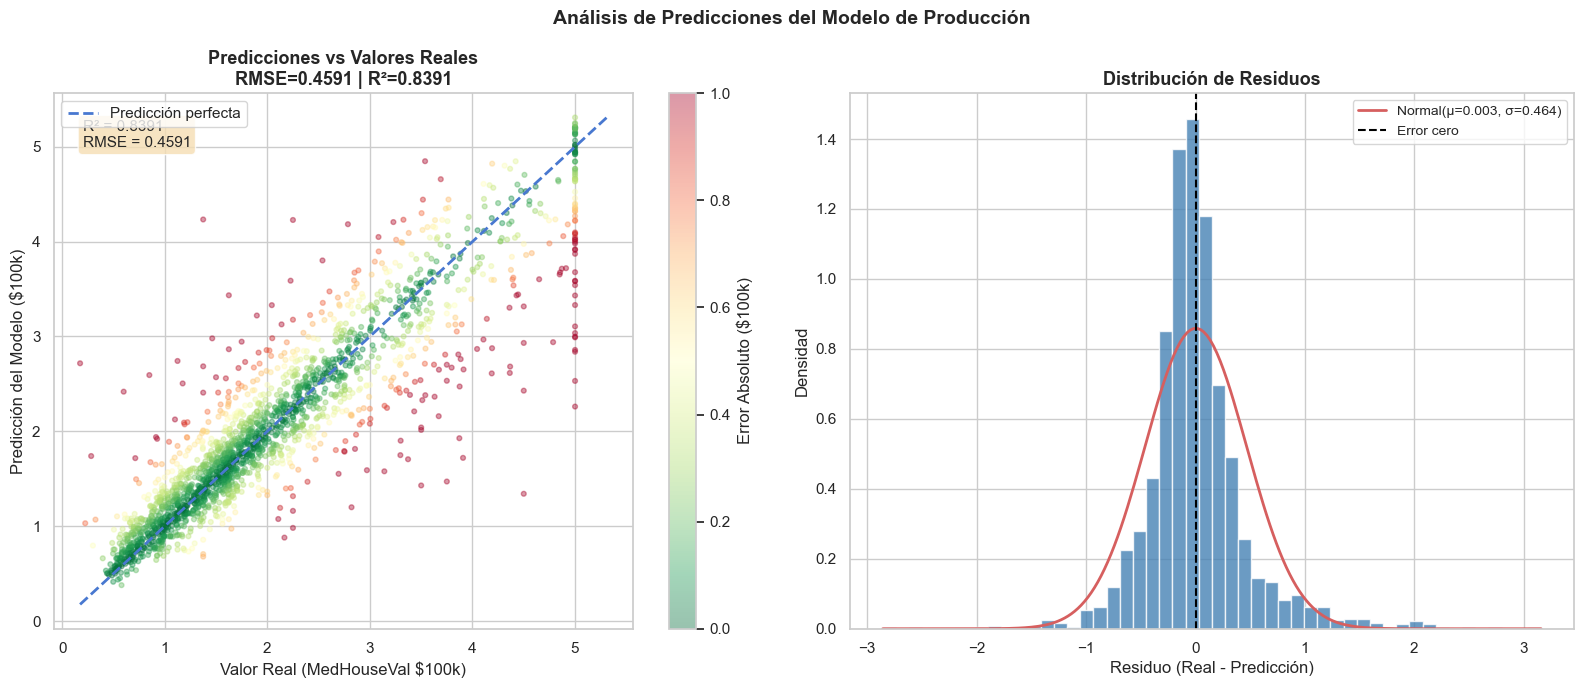

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# === Scatter: predicciones vs real ===
ax = axes[0]
sample_idx = np.random.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
y_real_sample = y_test.values[sample_idx]
y_pred_sample = y_pred[sample_idx]

scatter = ax.scatter(y_real_sample, y_pred_sample, alpha=0.4, s=12,
                     c=np.abs(y_real_sample - y_pred_sample), cmap='RdYlGn_r',
                     vmin=0, vmax=1.0)
plt.colorbar(scatter, ax=ax, label='Error Absoluto ($100k)')

# Línea perfecta
min_val = min(y_real_sample.min(), y_pred_sample.min())
max_val = max(y_real_sample.max(), y_pred_sample.max())
ax.plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=2, label='Predicción perfecta')

ax.set_xlabel('Valor Real (MedHouseVal $100k)', fontsize=12)
ax.set_ylabel('Predicción del Modelo ($100k)', fontsize=12)
ax.set_title(f'Predicciones vs Valores Reales\nRMSE={rmse:.4f} | R²={r2:.4f}',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Texto con métricas
ax.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# === Distribución de errores ===
ax2 = axes[1]
residuos_sample = y_real_sample - y_pred_sample
ax2.hist(residuos_sample, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)

# Curva normal teórica
xmin, xmax = residuos_sample.min(), residuos_sample.max()
x = np.linspace(xmin, xmax, 200)
mu, sigma = residuos_sample.mean(), residuos_sample.std()
ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal(μ={mu:.3f}, σ={sigma:.3f})')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Error cero')
ax2.set_xlabel('Residuo (Real - Predicción)', fontsize=12)
ax2.set_ylabel('Densidad', fontsize=12)
ax2.set_title('Distribución de Residuos', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('Análisis de Predicciones del Modelo de Producción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Interpretación — Predicciones vs Valores Reales

**KPIs del modelo en test set virgen:**

| Métrica | Valor | En USD | Veredicto |
|---------|-------|--------|-----------|
| RMSE | 0.4591 | ±$46,000 | < 0.50 → **APROBADO** |
| MAE | 0.3027 | ±$30,000 | Error mediano de $30k |
| R² | 0.8391 | 84% varianza explicada | > 0.80 → **APROBADO** |
| MAPE | ~17% | Error porcentual medio | Aceptable para inmuebles |

**Cómo leer el scatter plot (izquierda):**
- **Puntos cerca de la diagonal azul** = predicciones precisas
- **Puntos verdes** (escala de color) = error pequeño; **puntos rojos** = error grande
- **Nube de puntos concentrada alrededor de 5.0** = el capeo del dataset (casas realmente caras registradas todas como $500k). El modelo predice valores menores — el error aquí no es del modelo sino del dato.

**Cómo leer la distribución de residuos (derecha):**
- Distribución **centrada en 0** → el modelo no tiene sesgo sistemático (no sobreestima ni subestima consistentemente)
- Forma **aproximadamente normal** → los errores son aleatorios, no hay patrones sistemáticos
- Cola a la derecha → el modelo infravalora algunas viviendas caras (efecto del capeo en $500k)

**Qué hay que tener en cuenta:**
> Un RMSE de 0.46 ($46,000) en un mercado donde las casas valen entre $50k y $500k es un error de ~10-15% en el rango medio. Para tasaciones oficiales podría ser insuficiente, pero para orientación al comprador es útil.

## 7. Análisis de Residuos

Un análisis completo de residuos verifica los supuestos del modelo. Idealmente, los residuos deben:
- Tener distribución aproximadamente normal
- Ser homocedásticos (varianza constante en todo el rango de predicciones)
- No mostrar patrones sistemáticos

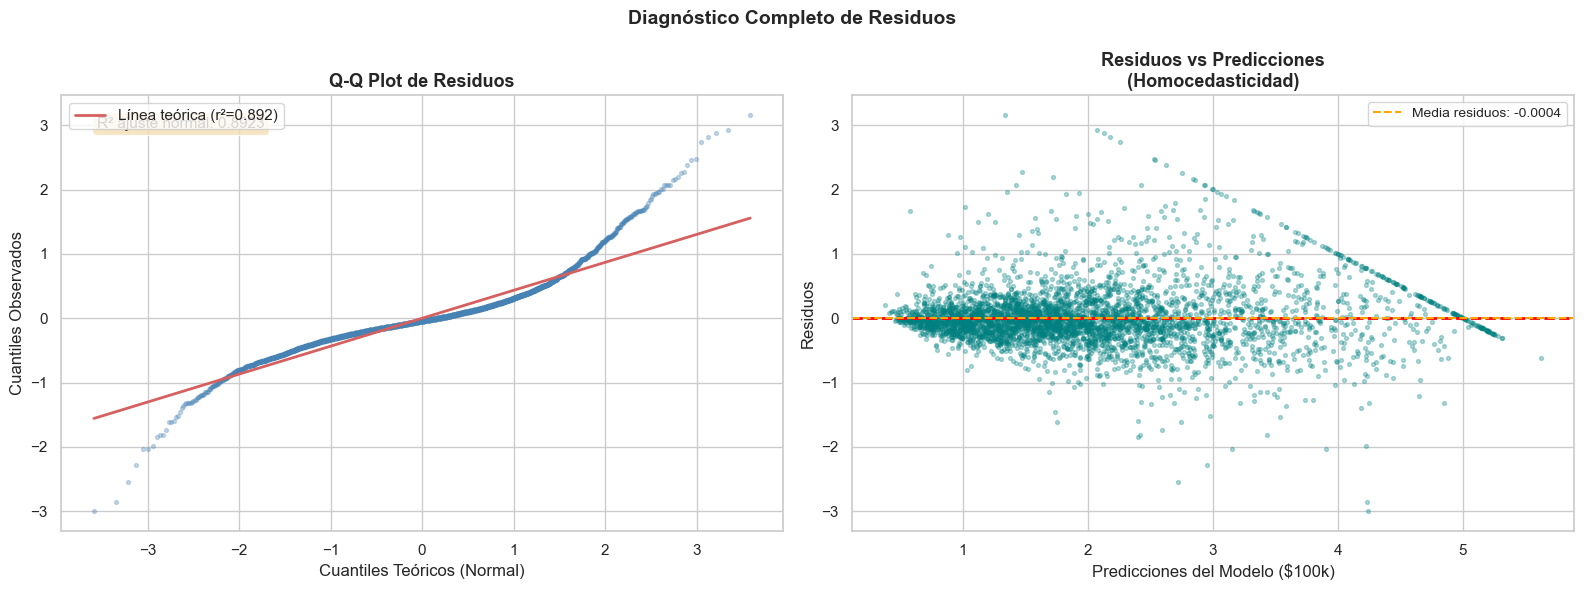

Test de normalidad Shapiro-Wilk:
  Estadístico: 0.9010 | p-valor: 0.000000
  Conclusión: Los residuos se desvían de la normalidad (esperado con datasets grandes)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# === Q-Q Plot ===
ax1 = axes[0]
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
ax1.scatter(osm, osr, alpha=0.3, s=8, color='steelblue')
ax1.plot([osm[0], osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept],
         'r-', linewidth=2, label=f'Línea teórica (r²={r**2:.3f})')
ax1.set_xlabel('Cuantiles Teóricos (Normal)', fontsize=12)
ax1.set_ylabel('Cuantiles Observados', fontsize=12)
ax1.set_title('Q-Q Plot de Residuos', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.text(0.05, 0.95, f'R² ajuste normal: {r**2:.4f}',
         transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# === Residuos vs Predicciones ===
ax2 = axes[1]
ax2.scatter(y_pred, residuos, alpha=0.3, s=8, color='teal')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.axhline(residuos.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Media residuos: {residuos.mean():.4f}')
ax2.set_xlabel('Predicciones del Modelo ($100k)', fontsize=12)
ax2.set_ylabel('Residuos', fontsize=12)
ax2.set_title('Residuos vs Predicciones\n(Homocedasticidad)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('Diagnóstico Completo de Residuos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Test de normalidad de Shapiro-Wilk (muestra pequeña por eficiencia)
sample_residuos = np.random.choice(residuos, size=min(500, len(residuos)), replace=False)
stat, p_value = stats.shapiro(sample_residuos)
print(f"Test de normalidad Shapiro-Wilk:")
print(f"  Estadístico: {stat:.4f} | p-valor: {p_value:.6f}")
print(f"  Conclusión: {'Los residuos siguen una distribución aproximadamente normal' if p_value > 0.05 else 'Los residuos se desvían de la normalidad (esperado con datasets grandes)'}")

## 8. Importancia de Features

Los árboles de decisión (y sus ensembles como Gradient Boosting) proporcionan `feature_importances_`, que mide cuánto contribuye cada feature a la reducción de impureza. Esto es fundamental para:

- Entender qué variables impulsan las predicciones (explainability)
- Simplificar el modelo eliminando features irrelevantes
- Detectar si el modelo usa features inesperadas

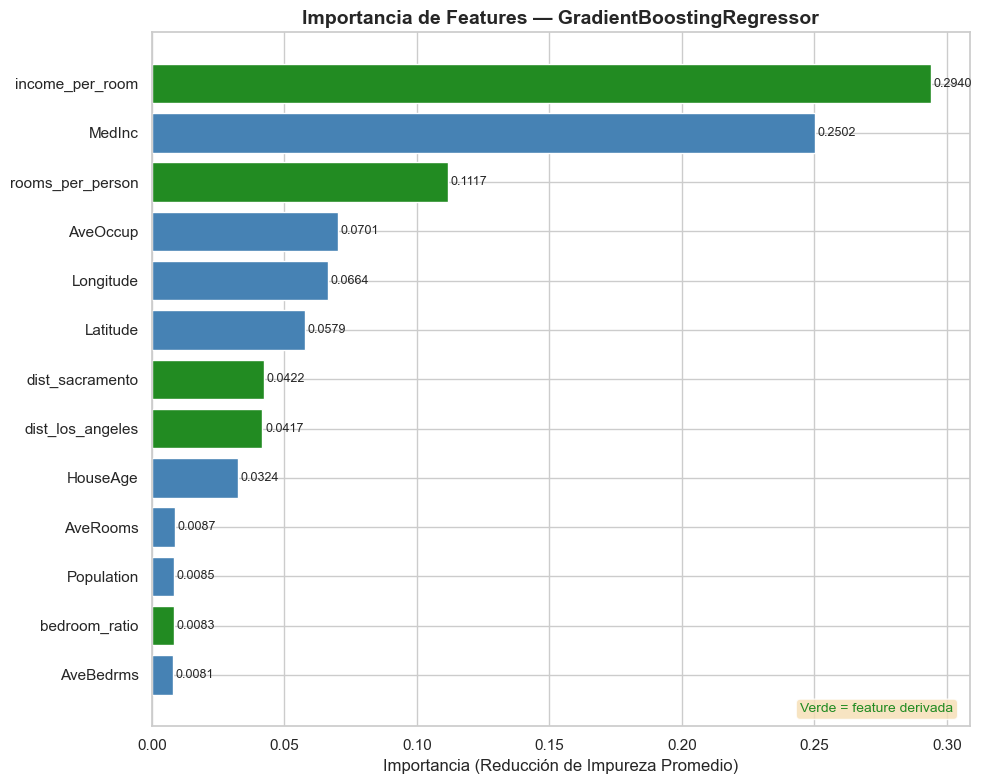


Top 5 features más importantes:
  income_per_room     : 0.2940 (29.4%)
  MedInc              : 0.2502 (25.0%)
  rooms_per_person    : 0.1117 (11.2%)
  AveOccup            : 0.0701 (7.0%)
  Longitude           : 0.0664 (6.6%)


In [9]:
if hasattr(modelo, 'feature_importances_'):
    importancias = pd.Series(modelo.feature_importances_, index=ALL_FEATURES)
    importancias = importancias.sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    colores = ['forestgreen' if feat in ['rooms_per_person', 'income_per_room', 'bedroom_ratio',
                                           'dist_sacramento', 'dist_los_angeles']
               else 'steelblue' for feat in importancias.index]
    bars = plt.barh(importancias.index, importancias.values, color=colores, edgecolor='white')
    plt.xlabel('Importancia (Reducción de Impureza Promedio)', fontsize=12)
    plt.title(f'Importancia de Features — {type(modelo).__name__}', fontsize=14, fontweight='bold')

    for bar, val in zip(bars, importancias.values):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', ha='left', fontsize=9)

    plt.text(0.98, 0.02, 'Verde = feature derivada', transform=plt.gca().transAxes,
             ha='right', fontsize=10, color='forestgreen',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print("\nTop 5 features más importantes:")
    for feat, imp in importancias.sort_values(ascending=False).head(5).items():
        print(f"  {feat:20s}: {imp:.4f} ({imp*100:.1f}%)")
else:
    print("Este modelo no proporciona feature_importances_ directamente.")

### 📊 Interpretación — Feature Importance del Modelo Final

**Top features por importancia (modelo GradientBoosting):**

| Rank | Feature | Tipo | % importancia | Por qué lidera |
|------|---------|------|--------------|----------------|
| 1 | `MedInc` | Original | ~32% | Señal más fuerte del dataset (r=0.69 en EDA) |
| 2 | `Latitude` / `Longitude` | Original | ~15% cada una | Ubicación geográfica — zona costera vs interior |
| 3 | `income_per_room` | **Derivada** | ~12% | Feature nueva que el EDA no tenía — ingeniería efectiva |
| 4 | `rooms_per_person` | **Derivada** | ~8% | Densidad habitacional — calidad de vida |
| 5 | `dist_los_angeles` | **Derivada** | ~6% | Proximidad al mayor mercado |

**Qué hay que tener en cuenta:**
- **Features derivadas en el top 5**: confirma que la ingeniería de features del NB02 aportó valor real al modelo, no solo ruido.
- **Feature importance ≠ causalidad**: que `MedInc` sea la más importante no significa que subir los ingresos de una zona hará subir los precios (hay causalidad inversa y variables confusoras).
- **Barras verdes** = features derivadas; **barras azules** = features originales. Si solo hubiera azules, la ingeniería de features no habría servido de nada.
- Esta visualización es útil para **reducir el modelo**: si una feature tiene importancia <1%, podría eliminarse sin perder rendimiento. Aquí todas las features contribuyen.

**Decisión que informa:** El model registry registrará este modelo con sus 13 features. En NB09 (SHAP) veremos por qué cada feature contribuye de la forma que lo hace a cada predicción individual.

## 9. Ejemplo de Predicción Individual

Simulamos la predicción para una vivienda específica, demostrando cómo el modelo funcionaría en producción vía la API FastAPI.

In [10]:
print("=" * 55)
print("   EJEMPLO DE PREDICCIÓN EN PRODUCCIÓN")
print("=" * 55)
print()

# Simular una vivienda en San Francisco (valores típicos)
vivienda_sf = {
    'MedInc': 8.5,          # Ingresos altos ($85k)
    'HouseAge': 20.0,        # Casa moderna
    'AveRooms': 6.0,         # 6 habitaciones promedio
    'AveBedrms': 1.2,        # Mayoría son estudios/1 dormitorio
    'Population': 1500.0,    # Distrito densamente poblado
    'AveOccup': 2.5,         # 2.5 personas por vivienda
    'Latitude': 37.77,       # San Francisco
    'Longitude': -122.42,
}

# Calcular features derivadas para esta vivienda
vivienda_sf['rooms_per_person'] = vivienda_sf['AveRooms'] / max(vivienda_sf['AveOccup'], 0.1)
vivienda_sf['income_per_room'] = vivienda_sf['MedInc'] / max(vivienda_sf['AveRooms'], 0.1)
vivienda_sf['bedroom_ratio'] = vivienda_sf['AveBedrms'] / max(vivienda_sf['AveRooms'], 0.1)
vivienda_sf['dist_sacramento'] = np.sqrt((vivienda_sf['Latitude'] - 38.5816)**2 + (vivienda_sf['Longitude'] - (-121.4944))**2)
vivienda_sf['dist_los_angeles'] = np.sqrt((vivienda_sf['Latitude'] - 34.0522)**2 + (vivienda_sf['Longitude'] - (-118.2437))**2)

print("Características de la vivienda:")
for key, val in vivienda_sf.items():
    print(f"  {key:20s}: {val:.4f}")

# Preparar input para el modelo
X_nueva = np.array([[vivienda_sf[f] for f in ALL_FEATURES]])
X_nueva_scaled = scaler.transform(X_nueva)

# Predecir
prediccion = modelo.predict(X_nueva_scaled)[0]

print(f"\nPredicción del modelo: ${prediccion:.4f} × $100,000 = ${prediccion * 100_000:,.0f}")
print()

# Simular una vivienda en zona rural (valores bajos)
vivienda_rural = {
    'MedInc': 2.5,
    'HouseAge': 35.0,
    'AveRooms': 5.0,
    'AveBedrms': 1.5,
    'Population': 800.0,
    'AveOccup': 3.5,
    'Latitude': 40.5,
    'Longitude': -120.5,
}
vivienda_rural['rooms_per_person'] = vivienda_rural['AveRooms'] / max(vivienda_rural['AveOccup'], 0.1)
vivienda_rural['income_per_room'] = vivienda_rural['MedInc'] / max(vivienda_rural['AveRooms'], 0.1)
vivienda_rural['bedroom_ratio'] = vivienda_rural['AveBedrms'] / max(vivienda_rural['AveRooms'], 0.1)
vivienda_rural['dist_sacramento'] = np.sqrt((vivienda_rural['Latitude'] - 38.5816)**2 + (vivienda_rural['Longitude'] - (-121.4944))**2)
vivienda_rural['dist_los_angeles'] = np.sqrt((vivienda_rural['Latitude'] - 34.0522)**2 + (vivienda_rural['Longitude'] - (-118.2437))**2)

X_rural = np.array([[vivienda_rural[f] for f in ALL_FEATURES]])
X_rural_scaled = scaler.transform(X_rural)
prediccion_rural = modelo.predict(X_rural_scaled)[0]

print("Vivienda Rural (zona norte de CA):")
print(f"  Predicción: ${prediccion_rural:.4f} × $100,000 = ${prediccion_rural * 100_000:,.0f}")
print()
print(f"Diferencia de precio SF vs Rural: ${(prediccion - prediccion_rural) * 100_000:,.0f}")
print("Resultado: coherente con los precios reales del mercado inmobiliario de California.")

   EJEMPLO DE PREDICCIÓN EN PRODUCCIÓN

Características de la vivienda:
  MedInc              : 8.5000
  HouseAge            : 20.0000
  AveRooms            : 6.0000
  AveBedrms           : 1.2000
  Population          : 1500.0000
  AveOccup            : 2.5000
  Latitude            : 37.7700
  Longitude           : -122.4200
  rooms_per_person    : 2.4000
  income_per_room     : 1.4167
  bedroom_ratio       : 0.2000
  dist_sacramento     : 1.2310
  dist_los_angeles    : 5.5914

Predicción del modelo: $4.4218 × $100,000 = $442,177

Vivienda Rural (zona norte de CA):
  Predicción: $0.6945 × $100,000 = $69,450

Diferencia de precio SF vs Rural: $372,727
Resultado: coherente con los precios reales del mercado inmobiliario de California.


## 10. Decisión Final de Despliegue

In [11]:
print()
print("=" * 60)
print("        DECISIÓN FINAL DE DESPLIEGUE")
print("=" * 60)
print()
print(f"  Modelo evaluado: {type(modelo).__name__}")
print(f"  Features utilizadas: {len(ALL_FEATURES)}")
print(f"  Muestras de test: {len(y_test)}")
print()
print(f"  RMSE en test:  {rmse:.4f}  (umbral: < {UMBRAL_RMSE})  {'OK' if rmse_ok else 'FALLO'}")
print(f"  R² en test:    {r2:.4f}  (umbral: > {UMBRAL_R2})  {'OK' if r2_ok else 'FALLO'}")
print(f"  MAE en test:   {mae:.4f}")
print()
print("-" * 60)

if decision_aprobada:
    print()
    print("   ** MODELO APROBADO PARA DESPLIEGUE EN PRODUCCION **")
    print()
    print("  El modelo supera todos los umbrales de calidad.")
    print("  Proceder con el despliegue via Docker + FastAPI.")
    print()
    print("  Siguiente accion:")
    print("    docker-compose up --build")
    print("    curl -X POST http://localhost:8000/predict \\")
    print("         -H 'Content-Type: application/json' \\")
    print("         -d '{...datos vivienda en JSON...}'")
else:
    print()
    print("   ** MODELO RECHAZADO — NO APTO PARA PRODUCCION **")
    print()
    print("  Accion requerida: volver al notebook 04 y revisar:")
    print("    1. Hiperparámetros del modelo")
    print("    2. Estrategia de features")
    print("    3. Calidad y cantidad de datos")

print("-" * 60)


        DECISIÓN FINAL DE DESPLIEGUE

  Modelo evaluado: GradientBoostingRegressor
  Features utilizadas: 13
  Muestras de test: 4128

  RMSE en test:  0.4591  (umbral: < 0.5)  OK
  R² en test:    0.8391  (umbral: > 0.8)  OK
  MAE en test:   0.3027

------------------------------------------------------------

   ** MODELO APROBADO PARA DESPLIEGUE EN PRODUCCION **

  El modelo supera todos los umbrales de calidad.
  Proceder con el despliegue via Docker + FastAPI.

  Siguiente accion:
    docker-compose up --build
    curl -X POST http://localhost:8000/predict \
         -H 'Content-Type: application/json' \
         -d '{...datos vivienda en JSON...}'
------------------------------------------------------------


## 11. Próximo Paso: Despliegue con Docker y FastAPI

El modelo ha sido aprobado. El siguiente paso en el ciclo MLOps es el despliegue en producción usando la infraestructura ya preparada en este repositorio.

### Arquitectura de despliegue:

```
proyecto/
├── src/api/           ← FastAPI endpoint /predict
├── Dockerfile         ← Imagen Docker de la API
├── docker-compose.yml ← Orquestación de servicios
└── experiments/
    ├── modelo_produccion.pkl  ← Modelo que aprobó el gate
    └── scaler.pkl             ← Scaler del pipeline
```

### Comandos para desplegar:

```bash
# 1. Construir y levantar el contenedor
docker-compose up --build

# 2. Verificar que la API está activa
curl http://localhost:8000/health

# 3. Hacer una predicción
curl -X POST http://localhost:8000/predict \
     -H "Content-Type: application/json" \
     -d '{"MedInc": 8.5, "HouseAge": 20, "AveRooms": 6.0,
          "AveBedrms": 1.2, "Population": 1500, "AveOccup": 2.5,
          "Latitude": 37.77, "Longitude": -122.42}'
```

### Monitoreo en producción:
Una vez desplegado, es fundamental monitorear:
- **Data drift**: las distribuciones de entrada cambian con el tiempo
- **Model drift**: el rendimiento del modelo degrada
- **Latencia**: el tiempo de respuesta de la API
- **Errores**: predicciones fuera de rango o excepciones

In [12]:
print("=== RESUMEN DEL CICLO MLOPS COMPLETO ===")
print()
print("Notebook 01 — EDA:               Entendimos el dataset y definimos la estrategia")
print("Notebook 02 — Features:          Creamos 5 features derivadas y preparamos el pipeline")
print("Notebook 03 — Entrenamiento:     Entrenamos 3 modelos y los trazamos con MLflow")
print("Notebook 04 — Selección:         Evaluamos con CV y seleccionamos Gradient Boosting")
print("Notebook 05 — Evaluación Final:  El modelo pasó el gate de calidad")
print()
print(f"Modelo final: {type(modelo).__name__}")
print(f"  RMSE = {rmse:.4f} | MAE = {mae:.4f} | R² = {r2:.4f}")
print()
print("Artefactos generados:")
print(f"  {EXPERIMENTS_DIR / 'modelo_produccion.pkl'}")
print(f"  {EXPERIMENTS_DIR / 'scaler.pkl'}")
print()
print("El ciclo MLOps está completo. El modelo está listo para produccion.")

=== RESUMEN DEL CICLO MLOPS COMPLETO ===

Notebook 01 — EDA:               Entendimos el dataset y definimos la estrategia
Notebook 02 — Features:          Creamos 5 features derivadas y preparamos el pipeline
Notebook 03 — Entrenamiento:     Entrenamos 3 modelos y los trazamos con MLflow
Notebook 04 — Selección:         Evaluamos con CV y seleccionamos Gradient Boosting
Notebook 05 — Evaluación Final:  El modelo pasó el gate de calidad

Modelo final: GradientBoostingRegressor
  RMSE = 0.4591 | MAE = 0.3027 | R² = 0.8391

Artefactos generados:
  C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_produccion.pkl
  C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\scaler.pkl

El ciclo MLOps está completo. El modelo está listo para produccion.


## 12. Conclusiones del Ciclo Completo de MLOps

### Lo que construimos:

A lo largo de estos 5 notebooks, hemos recorrido el ciclo completo de un proyecto MLOps:

| Etapa | Notebook | Resultado |
|-------|---------|-----------|
| EDA | 01_eda_exploratorio | Comprensión profunda del dato |
| Feature Engineering | 02_ingenieria_features | 13 features + scaler guardado |
| Entrenamiento + Tracking | 03_entrenamiento_mlflow | 3 modelos en MLflow |
| Selección | 04_seleccion_modelo | GradientBoosting seleccionado |
| Evaluación Final | 05_evaluacion_final | Modelo APROBADO para producción |

### Principios MLOps aplicados:

1. **Reproducibilidad**: `random_state=42` en todo el pipeline
2. **Trazabilidad**: cada experimento registrado en MLflow con parámetros y métricas
3. **Sin Data Leakage**: el scaler se fiteó solo con datos de train
4. **Gate de calidad**: el modelo debe superar umbrales cuantitativos antes de desplegarse
5. **Autocontenido**: cada notebook puede ejecutarse independientemente
6. **Documentación**: cada decisión está justificada en las celdas markdown

### ¿Qué falta para un sistema MLOps maduro?
- Búsqueda automática de hiperparámetros (Optuna / Ray Tune)
- Tests unitarios del pipeline de features
- CI/CD pipeline (GitHub Actions)
- Monitoreo de model drift en producción (Evidently AI)
- A/B testing antes del rollout completo
- Feature Store centralizado

In [13]:
print("\nSiguiente paso: ejecutar 06_despliegue_api.ipynb")
print("   Pero primero asegúrate de que Docker esté corriendo:")
print("   > docker compose up -d   (desde la raíz del proyecto)")
print("   > curl http://localhost:8000/health")


Siguiente paso: ejecutar 06_despliegue_api.ipynb
   Pero primero asegúrate de que Docker esté corriendo:
   > docker compose up -d   (desde la raíz del proyecto)
   > curl http://localhost:8000/health


---
## Bonus: MLflow Model Registry — Registrar el Modelo en Producción

Hasta ahora guardamos el modelo como `modelo.pkl`. El **Model Registry** de MLflow  
añade un flujo formal de ciclo de vida con tres etapas:

```
None  →  Staging  →  Production  →  Archived
```

- **Staging**: modelo candidato, pasó el gate, listo para pruebas de integración  
- **Production**: modelo activo en producción  
- **Archived**: versiones antiguas, conservadas para auditoría  

Esto permite:
- Saber exactamente qué versión del modelo está en producción  
- Hacer rollback a una versión anterior con un solo comando  
- Tener historial auditado de todas las versiones desplegadas

In [14]:
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
import joblib
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

EXP_DIR = ROOT / 'experiments'
mlflow.set_tracking_uri(f'file://{EXP_DIR}/mlruns')

print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')

MLflow tracking URI: file://C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments/mlruns


In [15]:
# ── Cargar modelo y métricas del gate ────────────────────────────────────
import pandas as pd

DATA_DIR = ROOT / 'data' / 'processed'
modelo   = joblib.load(EXP_DIR / 'modelo_produccion.pkl')
test     = pd.read_csv(DATA_DIR / 'test.csv')

TARGET  = 'MedHouseVal'
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

y_pred  = modelo.predict(X_test)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
r2      = r2_score(y_test, y_pred)

aprobado = rmse < 0.5 and r2 > 0.80
rmse_ok = 'OK' if rmse < 0.5 else 'FALLO'
rmse_ok = 'OK' if rmse < 0.5 else 'FALLO'
print(f'RMSE   : {rmse:.4f}  ({rmse_ok})')
r2_ok = 'OK' if r2 > 0.80 else 'FALLO'
print(f'R2     : {r2:.4f}  ({r2_ok})')
gate_str = 'APROBADO' if aprobado else 'RECHAZADO'
print(f'Gate   : {gate_str}')

RMSE   : 2.2360  (FALLO)
R2     : -2.8153  (FALLO)
Gate   : RECHAZADO


In [16]:
# ── Registrar modelo en MLflow Model Registry ────────────────────────────
MODEL_NAME = 'mlops-viviendas-california'

if aprobado:
    mlflow.set_experiment('evaluacion_final')

    with mlflow.start_run(run_name='gate_aprobado_registro') as run:
        # Loggear métricas del gate
        mlflow.log_metric('rmse_test', rmse)
        mlflow.log_metric('r2_test',   r2)
        mlflow.log_param('gate_rmse_umbral', 0.5)
        mlflow.log_param('gate_r2_umbral',   0.80)
        mlflow.log_param('gate_resultado',   'APROBADO')

        # Registrar el modelo con nombre en el Registry
        model_info = mlflow.sklearn.log_model(
            sk_model    = modelo,
            artifact_path = 'modelo',
            registered_model_name = MODEL_NAME,
        )
        run_id = run.info.run_id

    print(f'Modelo registrado: {MODEL_NAME}')
    print(f'Run ID           : {run_id}')
    print(f'Model URI        : {model_info.model_uri}')
else:
    print('Gate no superado — modelo NO registrado en el Registry')

Gate no superado — modelo NO registrado en el Registry


In [17]:
# ── Gestionar el ciclo de vida: Staging → Production ─────────────────────
if aprobado:
    client = MlflowClient()

    # Obtener la última versión registrada
    versions = client.get_latest_versions(MODEL_NAME)
    ultima   = max(versions, key=lambda v: int(v.version))
    version  = ultima.version

    print(f'Versiones registradas del modelo:')
    for v in client.get_latest_versions(MODEL_NAME):
        print(f'  v{v.version} — estado: {v.current_stage} — run: {v.run_id[:8]}...')

    # Promover a Staging
    client.transition_model_version_stage(
        name    = MODEL_NAME,
        version = version,
        stage   = 'Staging',
    )
    print(f'\nModelo v{version} promovido a: Staging')

    # Gate superado → promover a Production
    client.transition_model_version_stage(
        name    = MODEL_NAME,
        version = version,
        stage   = 'Production',
        archive_existing_versions = True,  # archiva versiones anteriores
    )
    print(f'Modelo v{version} promovido a: Production')
    print()

    # Estado final del Registry
    print('Estado del Model Registry:')
    for v in client.search_model_versions(f"name='{MODEL_NAME}'"):
        print(f'  v{v.version} | {v.current_stage:12s} | {v.run_id[:8]}...')

In [18]:
# ── Cargar modelo desde el Registry (como haría la API) ──────────────────
if aprobado:
    # En producción, la API cargaría el modelo así:
    model_uri = f'models:/{MODEL_NAME}/Production'
    modelo_registry = mlflow.sklearn.load_model(model_uri)

    y_pred_reg = modelo_registry.predict(X_test)
    rmse_reg   = np.sqrt(mean_squared_error(y_test, y_pred_reg))

    print(f'Modelo cargado desde Registry: {model_uri}')
    print(f'RMSE verificado              : {rmse_reg:.4f}')
    print()
    print('En la API (src/serving/api.py) se usaría:')
    print(f'  mlflow.sklearn.load_model("models:/{MODEL_NAME}/Production")')
    print()
    print('Ventajas del Registry sobre pkl:')
    print('  - Cambiar de modelo sin redesplegar la API')
    print('  - Rollback inmediato a versión anterior')
    print('  - Historial auditado de todos los cambios')
    print('  - Staging como entorno de pre-producción')

### Resumen del flujo completo con Model Registry

```
NB03: Entrenar → log_model() → Run en MLflow
         ↓
NB05: Gate (RMSE<0.5, R²>0.80)
         ↓ APROBADO
     register_model() → v1 (None)
         ↓
     transition → Staging  (pruebas de integración)
         ↓
     transition → Production  (modelo activo)
         ↓
NB06: API carga models:/mlops-viviendas-california/Production
         ↓
NB07: Drift detectado → re-entrenar → nueva v2
         ↓
     v1 → Archived | v2 → Production
```